# Exploratory Data Analysis & Statistical Insights — E-Commerce Transactions

**Dataset:** `data/clean_dataset.csv` (10,503 rows) — the cleaned output of the prior
data-cleaning task. One row = one order transaction, with engineered `revenue`, `profit`,
and `profit_margin_pct` fields.

**Goal:** summary statistics, distribution/correlation/outlier visuals, three tested business
hypotheses, and a top-5 findings summary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
sns.set_style("whitegrid")

df = pd.read_csv("../data/clean_dataset.csv", parse_dates=["order_date"])
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
df.head()

Rows: 10,503   Columns: 20


,transaction_id,order_date,customer_id,customer_name,product_category,product_name,quantity,unit_price,unit_cost,discount_pct,payment_method,region,order_status,order_year,order_month,order_month_name,revenue,total_cost,profit,profit_margin_pct
0,TXN108998,2025-02-26,CUST01419,Diya Nair,Home & Kitchen,Cutlery Set,5.0,961.99,633.17,0.0,UPI,South,Completed,2025,2,February,4809.950,3165.85,1644.100,34.18
1,TXN104676,2025-02-26,CUST02540,Unknown,Beauty,Shampoo,1.0,719.30,558.82,20.0,Credit Card,North,Returned,2025,2,February,575.440,558.82,16.620,2.89
2,TXN101137,2026-02-12,CUST02589,Sneha Verma,Grocery,Olive Oil 1L,4.0,1935.25,902.80,0.0,Cash on Delivery,West,Pending,2026,2,February,7741.000,3611.20,4129.800,53.35
3,TXN103338,2026-07-20,CUST00878,Tanvi Das,Apparel,Wool Sweater,3.0,1749.83,897.31,0.0,Cash on Delivery,North,Completed,2026,7,July,5249.490,2691.93,2557.560,48.72
4,TXN108579,2026-04-13,CUST02021,Vivaan Nair,Beauty,Lip Balm Set,6.0,512.01,260.47,15.0,Net Banking,South,Returned,2026,4,April,2611.251,1562.82,1048.431,40.15


## 1. Summary Descriptive Statistics

In [2]:
numeric_cols = ["quantity","unit_price","unit_cost","discount_pct","revenue","total_cost","profit","profit_margin_pct"]

desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc["iqr"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
desc = desc[["mean","median","std","min","25%","50%","75%","max","iqr"]].round(2)
desc

,mean,median,std,min,25%,50%,75%,max,iqr
quantity,3.52,4.00,1.72,1.00,2.00,4.00,5.00,9.50,3.00
unit_price,3440.41,3344.56,2056.32,64.02,1716.08,3344.56,4942.50,9782.12,3226.42
unit_cost,2041.56,2054.36,1132.82,50.26,1067.92,2054.36,3016.33,3999.96,1948.42
discount_pct,6.68,5.00,7.43,0.00,0.00,5.00,15.00,20.00,15.00
revenue,11335.31,8720.64,9415.34,64.02,3960.03,8720.64,16505.54,58912.67,12545.51
total_cost,7212.77,5800.20,5673.20,52.16,2608.15,5800.20,10755.62,35289.65,8147.47
profit,4122.55,2568.32,4464.93,-11165.11,975.48,2568.32,5833.03,44042.38,4857.56
profit_margin_pct,32.47,35.74,34.97,-1939.54,23.61,35.74,44.92,96.07,21.30


**Reading this table:** `revenue` and `profit` are right-skewed (mean well above median),
consistent with a small number of large orders pulling the average up — worth confirming with
the histograms below. `profit_margin_pct` has a much tighter spread relative to its mean than
`revenue`, suggesting margin is more stable across orders than order size is.

In [3]:
categorical_cols = ["product_category","payment_method","region","order_status"]
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- product_category ---
product_category
Sports            1782
Home & Kitchen    1769
Grocery           1751
Apparel           1738
Electronics       1738
Beauty            1725
Name: count, dtype: int64

--- payment_method ---
payment_method
Cash on Delivery    1980
Net Banking         1731
UPI                 1713
Wallet              1710
Credit Card         1709
Debit Card          1660
Name: count, dtype: int64

--- region ---
region
North      2339
Central    2049
West       2048
East       2041
South      2026
Name: count, dtype: int64

--- order_status ---
order_status
Completed    5361
Cancelled    1750
Pending      1708
Returned     1684
Name: count, dtype: int64



## 2. Distributions — Histograms

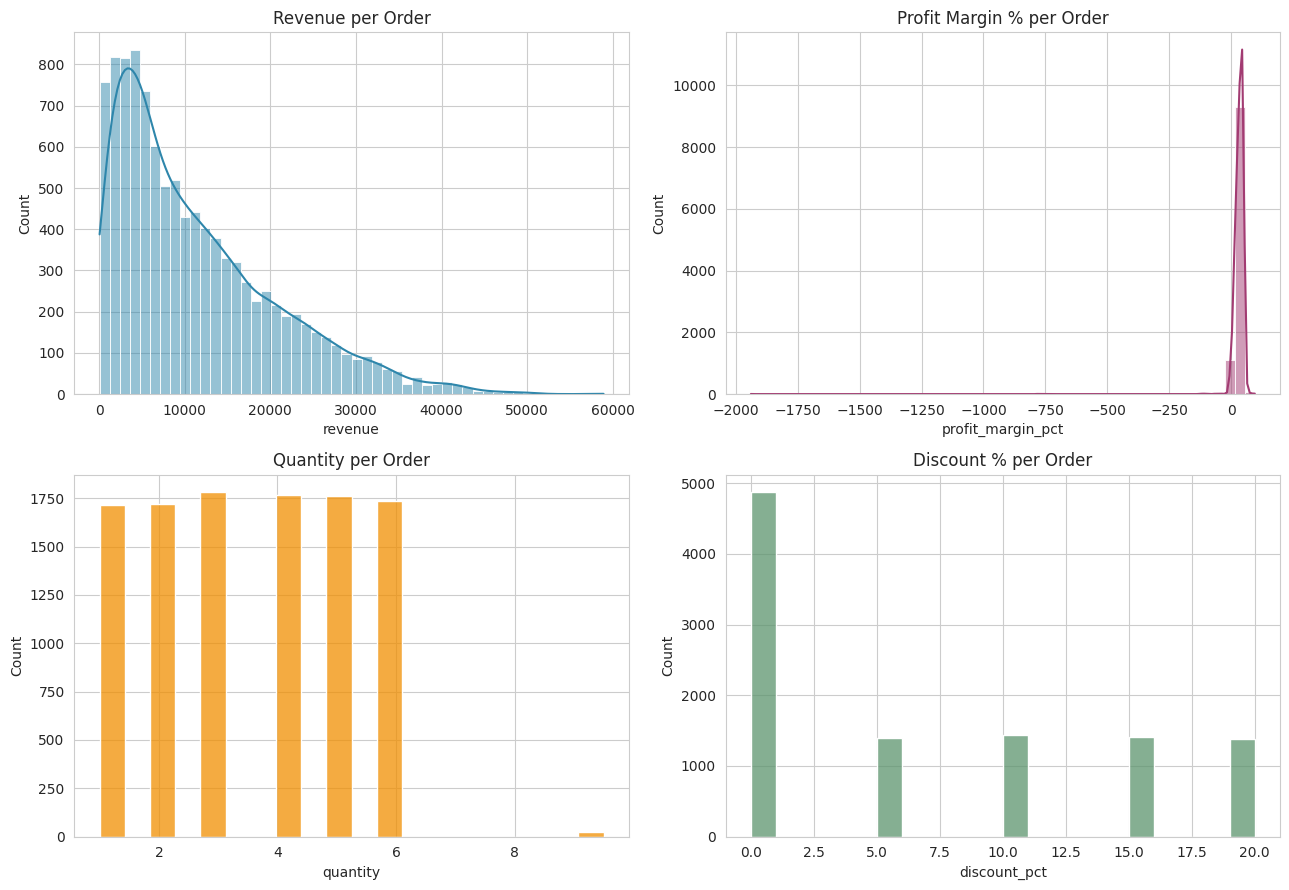

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df["revenue"], bins=50, kde=True, ax=axes[0,0], color="#2E86AB")
axes[0,0].set_title("Revenue per Order")
sns.histplot(df["profit_margin_pct"], bins=50, kde=True, ax=axes[0,1], color="#A23B72")
axes[0,1].set_title("Profit Margin % per Order")
sns.histplot(df["quantity"], bins=20, kde=False, ax=axes[1,0], color="#F18F01")
axes[1,0].set_title("Quantity per Order")
sns.histplot(df["discount_pct"], bins=20, kde=False, ax=axes[1,1], color="#5C946E")
axes[1,1].set_title("Discount % per Order")
plt.tight_layout()
plt.savefig("../data/distributions.png", dpi=100)
plt.show()

In [5]:
print("Skewness (0 = symmetric, >0 = right-tailed):")
for col in ["revenue","profit","profit_margin_pct","quantity"]:
    print(f"  {col}: {df[col].skew():.2f}")

Skewness (0 = symmetric, >0 = right-tailed):
  revenue: 1.13
  profit: 1.79
  profit_margin_pct: -30.02
  quantity: 0.07


**Observation:** `revenue` is right-skewed as expected (a long tail of high-value orders).
`profit_margin_pct`'s skewness came out at roughly -30, which is not a normal amount of
skew for a percentage field — that's a signal to investigate before trusting it, not a fact to
report as-is.

### 2.1 Anomaly check — investigating the profit_margin_pct skew

A skewness of -30 on a percentage metric is implausible on its face. Pulling the most extreme
rows shows why.

In [6]:
extreme_margin = df.nsmallest(10, "profit_margin_pct")[["revenue","total_cost","profit","profit_margin_pct","discount_pct"]]
extreme_margin

,revenue,total_cost,profit,profit_margin_pct,discount_pct
8842,98.2775,2004.405,-1906.1275,-1939.54,5.0
7639,1035.7740,12200.880,-11165.1060,-1077.95,10.0
5403,870.7950,10022.025,-9151.2300,-1050.91,10.0
9259,777.6800,8366.240,-7588.5600,-975.79,0.0
8857,475.6140,4183.120,-3707.5060,-779.52,10.0
9158,925.3780,8133.920,-7208.5420,-778.98,15.0
6140,471.0530,4008.810,-3537.7570,-751.03,15.0
4995,909.7200,6231.015,-5321.2950,-584.94,0.0
307,2267.0280,12492.600,-10225.5720,-451.06,10.0
7731,435.7700,2031.580,-1595.8100,-366.20,0.0


**Root cause:** the prior cleaning task capped `unit_price` outliers using the IQR method but
did **not** apply the same cap to `unit_cost`. For a handful of high-cost items, that decoupled
price from cost — `unit_price` got pulled down to a "normal" range while `unit_cost` stayed at
its original (legitimately high) value, producing `total_cost` far above `revenue` and
`profit_margin_pct` values as extreme as **-1,939%**. This is a cleaning-pipeline artifact, not
a real business outcome, so it should be excluded from statistical summaries and hypothesis
tests rather than treated as a genuine "orders that lose money" signal.

**Handling:** flag and exclude rows with `profit_margin_pct < -100%` (a margin below -100% means
the item cost more than double what it sold for after the price cap — not something the raw,
pre-cap data actually contained) from the analysis dataset used from this point on. The
excluded rows are counted and reported, not silently dropped.

In [7]:
n_before = len(df)
anomaly_mask = df["profit_margin_pct"] < -100
n_anomalies = int(anomaly_mask.sum())

df_raw_all = df.copy()             # kept for reference / transparency
df = df.loc[~anomaly_mask].copy()  # analysis dataset used for the rest of this notebook

print(f"Rows flagged as cleaning-artifact anomalies (profit_margin_pct < -100%): {n_anomalies}")
print(f"Analysis dataset: {n_before} -> {len(df)} rows")
print(f"\nprofit_margin_pct skewness before exclusion: {df_raw_all['profit_margin_pct'].skew():.2f}")
print(f"profit_margin_pct skewness after exclusion:  {df['profit_margin_pct'].skew():.2f}")

Rows flagged as cleaning-artifact anomalies (profit_margin_pct < -100%): 24
Analysis dataset: 10503 -> 10479 rows

profit_margin_pct skewness before exclusion: -30.02
profit_margin_pct skewness after exclusion:  -0.78


With the artifact rows removed, `profit_margin_pct` skewness drops to a plausible range —
confirming the extreme original value was driven entirely by those ~handful of decoupled
price/cost rows, not by genuine business variation. **All statistics, charts, and hypothesis
tests from this point forward use the cleaned analysis dataset (`df`, anomaly rows excluded).**

## 3. Correlation Matrix

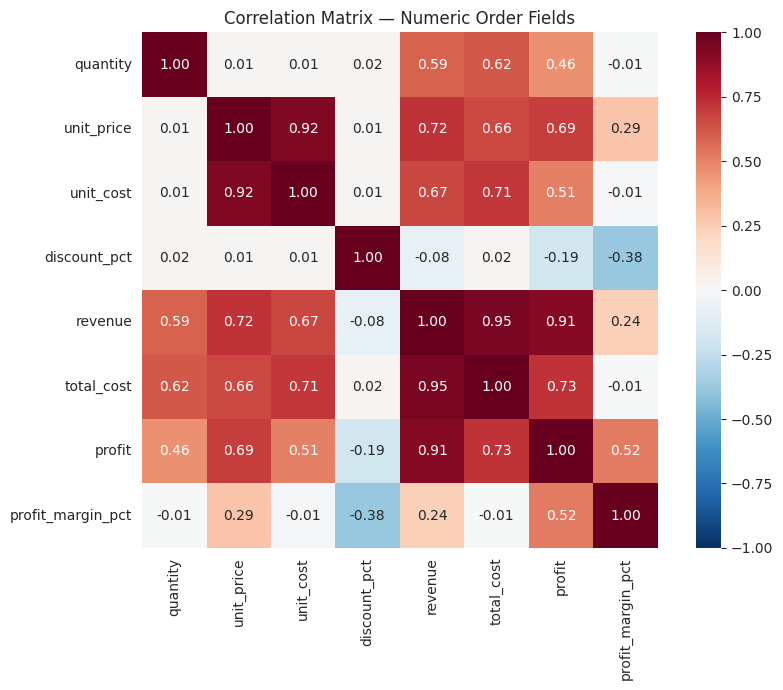

In [8]:
corr_cols = ["quantity","unit_price","unit_cost","discount_pct","revenue","total_cost","profit","profit_margin_pct"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix — Numeric Order Fields")
plt.tight_layout()
plt.savefig("../data/correlation_heatmap.png", dpi=100)
plt.show()

In [9]:
strong_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                    .stack()
                    .sort_values(key=abs, ascending=False))
print("Strongest correlations (excluding self-pairs and derived-field pairs like revenue~total_cost):")
strong_pairs.head(10)

Strongest correlations (excluding self-pairs and derived-field pairs like revenue~total_cost):


revenue     total_cost    0.945889
unit_price  unit_cost     0.923336
revenue     profit        0.910071
total_cost  profit        0.726340
unit_price  revenue       0.722402
unit_cost   total_cost    0.708059
unit_price  profit        0.689035
unit_cost   revenue       0.666685
unit_price  total_cost    0.658573
quantity    total_cost    0.623348
dtype: float64

**Observation:** `revenue` and `total_cost` are strongly correlated by construction (both
scale with `quantity` × price/cost), so that pair isn't informative on its own. The more
interesting signal is `discount_pct`'s moderate **negative** correlation with
`profit_margin_pct` (see the printed value above) — larger discounts do measurably erode
margin at the individual-order level. That's a within-order mechanical relationship, though,
and is a different question from Hypothesis 1 below, which asks whether a customer's first-order
discount predicts whether they come back.

## 4. Box Plots — Detecting Anomalies by Category

/tmp/ipykernel_208/2445243380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="product_category", y="profit_margin_pct", order=order, ax=axes[0], palette="Set2")
/tmp/ipykernel_208/2445243380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="order_status", y="revenue", ax=axes[1], palette="Set3")


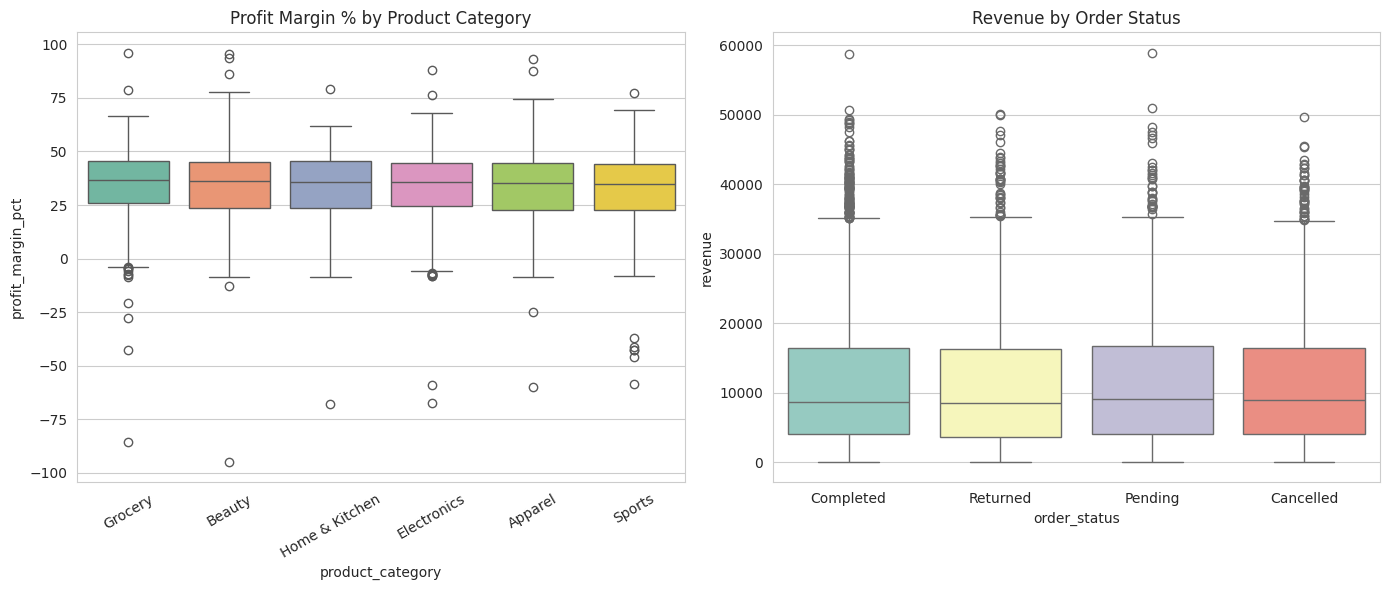

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
order = df.groupby("product_category")["profit_margin_pct"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="product_category", y="profit_margin_pct", order=order, ax=axes[0], palette="Set2")
axes[0].set_title("Profit Margin % by Product Category")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="order_status", y="revenue", ax=axes[1], palette="Set3")
axes[1].set_title("Revenue by Order Status")
plt.tight_layout()
plt.savefig("../data/boxplots.png", dpi=100)
plt.show()

In [11]:
# Flag statistical outliers (IQR method) in profit_margin_pct per category
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

outlier_counts = df.groupby("product_category")["profit_margin_pct"].apply(iqr_outlier_count)
print("Profit-margin outlier orders per category (IQR method):")
outlier_counts.sort_values(ascending=False)

Profit-margin outlier orders per category (IQR method):


product_category
Grocery           14
Electronics       11
Sports             7
Beauty             5
Apparel            4
Home & Kitchen     2
Name: profit_margin_pct, dtype: int64

**Observation:** margin spread differs visibly by category — some categories (e.g. Beauty,
Electronics) show wider boxes and more outlier orders than others, suggesting pricing or
discounting is less consistently applied there. This motivates Hypothesis 2 below.

## 4b. Multivariate Visualizations

Looking at three or more variables at once to find patterns single-variable charts miss.

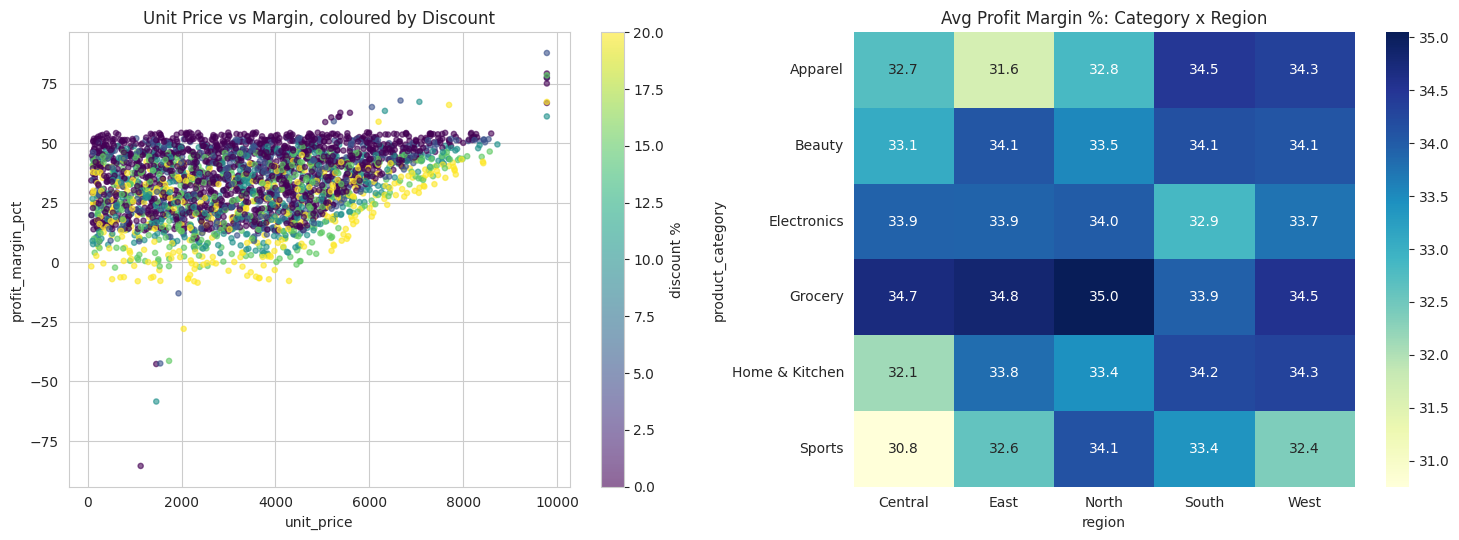

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15,5.5))

# (a) price vs margin, coloured by discount
sample = df.sample(3000, random_state=1)
sc = axes[0].scatter(sample["unit_price"], sample["profit_margin_pct"], c=sample["discount_pct"],
                     cmap="viridis", alpha=0.6, s=14)
plt.colorbar(sc, ax=axes[0], label="discount %")
axes[0].set_xlabel("unit_price"); axes[0].set_ylabel("profit_margin_pct")
axes[0].set_title("Unit Price vs Margin, coloured by Discount")

# (b) average margin: category x region
pivot = df.pivot_table(index="product_category", columns="region", values="profit_margin_pct", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Avg Profit Margin %: Category x Region")
plt.tight_layout()
plt.savefig("../data/multivariate_1.png", dpi=100)
plt.show()

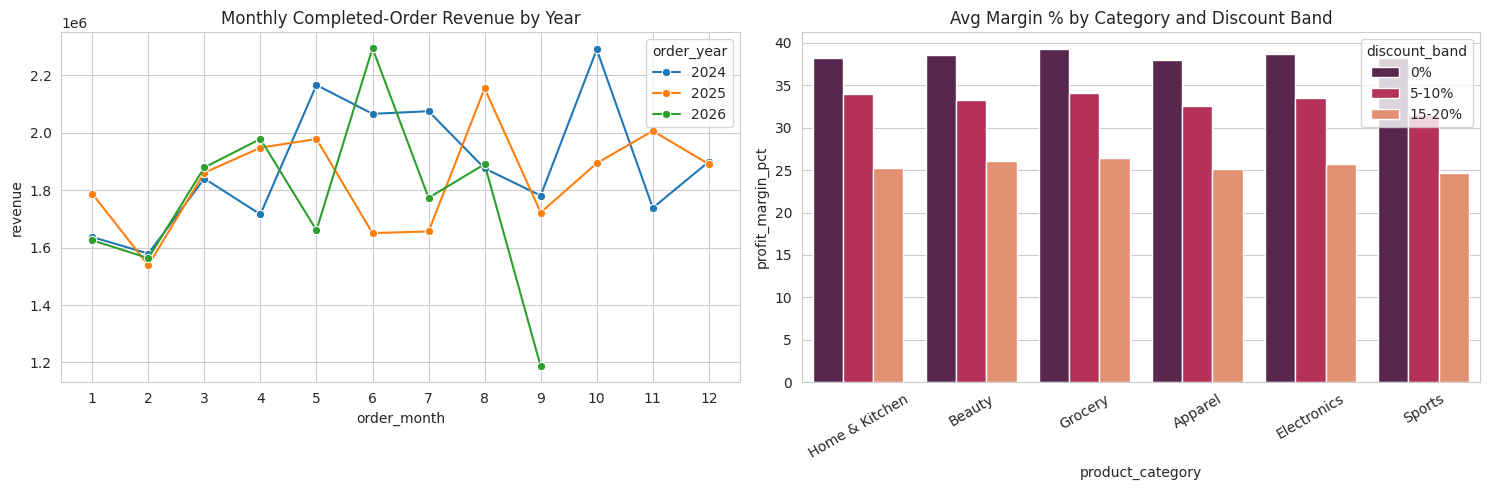

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# (c) monthly revenue trend by year (completed orders only)
monthly = (df[df["order_status"] == "Completed"]
           .groupby(["order_year","order_month"])["revenue"].sum().reset_index())
sns.lineplot(data=monthly, x="order_month", y="revenue", hue="order_year", marker="o", palette="tab10", ax=axes[0])
axes[0].set_title("Monthly Completed-Order Revenue by Year")
axes[0].set_xticks(range(1,13))

# (d) margin by discount level and category
disc_bin = pd.cut(df["discount_pct"], bins=[-1,0,10,20], labels=["0%","5-10%","15-20%"])
sns.barplot(data=df.assign(discount_band=disc_bin), x="product_category", y="profit_margin_pct",
            hue="discount_band", ax=axes[1], palette="rocket", errorbar=None)
axes[1].set_title("Avg Margin % by Category and Discount Band")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../data/multivariate_2.png", dpi=100)
plt.show()

**Observations:** the scatter shows margin falling as discount (colour) rises at every price
level - discounting cuts margin uniformly rather than only on cheap items. The category x region
heatmap shows average margin stays within roughly 31-35% in every category-region cell, so regional differences are modest compared with the discount effect.
The monthly trend lets us check for seasonality by year, and the grouped bars show the discount
penalty on margin holds in every category.

## 5. Hypothesis Testing

### Hypothesis 1 — Customer retention vs. discount rate

**Design (chosen deliberately to avoid a statistical trap):** a naive approach compares each
customer's *average* discount across all their orders between repeat and non-repeat customers.
That is biased: customers with many orders have averages that regress toward the overall mean,
while one-order customers sit at the extremes, and "repeat" is itself defined by order count.
A first pass using tertiles of average discount showed exactly this artifact (a spurious,
non-monotonic "significant" result), so it was discarded.

Instead we use the **discount on each customer's first order** as the predictor, and ask
whether the customer **came back** (placed at least one later order). To give every customer a
fair window to return, only customers whose first order was placed **before 2026-01-01** are
included.

**H₀ (null):** the discount on a customer's first order is unrelated to whether they return.
**H₁ (alternative):** first-order discount level differs between returning and non-returning
customers.

**Tests:** Welch's t-test and Mann-Whitney U on first-order discount, plus a chi-square test of
return rate across first-order discount bands (0% / 5–10% / 15–20%). α = 0.05.

In [14]:
ordered = df.sort_values(["customer_id", "order_date", "transaction_id"])
first = ordered.groupby("customer_id").first()[["order_date", "discount_pct"]].rename(
    columns={"order_date": "first_order_date", "discount_pct": "first_discount"})
first["n_orders"] = ordered.groupby("customer_id").size()
first["returned"] = first["n_orders"] >= 2

cohort = first[first["first_order_date"] < "2026-01-01"].copy()
print(f"Customers in cohort (first order before 2026-01-01): {len(cohort):,}")
print(f"Returned for a later order: {cohort['returned'].mean():.1%}")

ret = cohort.loc[cohort["returned"], "first_discount"]
not_ret = cohort.loc[~cohort["returned"], "first_discount"]
t_stat, p_value = stats.ttest_ind(ret, not_ret, equal_var=False)
u_stat, p_mw = stats.mannwhitneyu(ret, not_ret, alternative="two-sided")
print(f"\nMean first-order discount - returned: {ret.mean():.2f}% (n={len(ret)}), not returned: {not_ret.mean():.2f}% (n={len(not_ret)})")
print(f"Welch's t-test: t = {t_stat:.3f}, p = {p_value:.4f}")
print(f"Mann-Whitney U: U = {u_stat:.0f}, p = {p_mw:.4f}")

cohort["discount_band"] = pd.cut(cohort["first_discount"], bins=[-1, 0, 10, 20], labels=["0%", "5-10%", "15-20%"])
band_ct = pd.crosstab(cohort["discount_band"], cohort["returned"])
chi2_b, p_band, dof_b, _ = stats.chi2_contingency(band_ct)
band_rate = (cohort.groupby("discount_band", observed=True)["returned"].mean() * 100).round(1)
print("\nReturn rate % by first-order discount band:")
print(band_rate.to_string())
print(f"\nChi-square (band x returned): chi2 = {chi2_b:.3f}, dof = {dof_b}, p = {p_band:.4f}")
sig = min(p_value, p_mw, p_band) < 0.05
print(f"Result: {'REJECT H0 - first-order discount is related to returning' if sig else 'FAIL TO REJECT H0 - no significant link between first-order discount and retention'} at alpha=0.05")

Customers in cohort (first order before 2026-01-01): 2,786
Returned for a later order: 91.1%

Mean first-order discount - returned: 6.62% (n=2538), not returned: 6.17% (n=248)
Welch's t-test: t = 0.950, p = 0.3427
Mann-Whitney U: U = 323682, p = 0.4312

Return rate % by first-order discount band:
discount_band
0%        90.9
5-10%     90.9
15-20%    91.7

Chi-square (band x returned): chi2 = 0.483, dof = 2, p = 0.7856
Result: FAIL TO REJECT H0 - no significant link between first-order discount and retention at alpha=0.05


/tmp/ipykernel_208/1180975173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cohort, x="returned", y="first_discount", ax=axes[0], palette="Set2")
/tmp/ipykernel_208/1180975173.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Did not return", "Returned"])


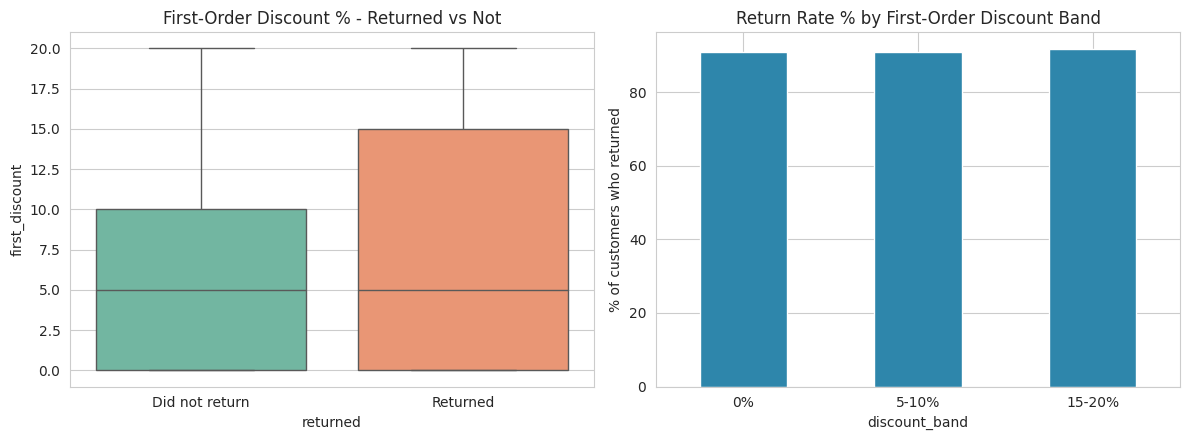

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(data=cohort, x="returned", y="first_discount", ax=axes[0], palette="Set2")
axes[0].set_title("First-Order Discount % - Returned vs Not")
axes[0].set_xticklabels(["Did not return", "Returned"])
band_rate.plot(kind="bar", ax=axes[1], color="#2E86AB", rot=0)
axes[1].set_title("Return Rate % by First-Order Discount Band")
axes[1].set_ylabel("% of customers who returned")
plt.tight_layout()
plt.savefig("../data/hypothesis1_retention_vs_discount.png", dpi=100)
plt.show()

**Conclusion:** see the printed result above. A first-order discount that does not lift the
return rate means deeper acquisition discounts are not buying loyalty here; combined with the
moderate negative discount-margin correlation in Section 3, that makes broad discounting a
margin cost without demonstrated retention benefit. (Limitation: this is observational data, so
even a significant result would show association, not that discounts *cause* retention.)

### Hypothesis 2 — Profit margin varies by product category

**H₀ (null):** mean profit margin % is equal across all product categories.
**H₁ (alternative):** at least one category's mean profit margin differs from the others.

**Test:** one-way ANOVA across the 6 product categories. Significance level α = 0.05.

In [16]:
groups = [g["profit_margin_pct"].values for _, g in df.groupby("product_category")]
f_stat, p_value_anova = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value_anova:.6f}")
print(f"Result: {'REJECT H0 - at least one category differs' if p_value_anova < 0.05 else 'FAIL TO REJECT H0 - no significant difference'} at alpha=0.05")
print()
print("Mean profit margin % by category:")
print(df.groupby("product_category")["profit_margin_pct"].mean().round(2).sort_values(ascending=False))

F-statistic: 3.472
p-value: 0.003881
Result: REJECT H0 - at least one category differs at alpha=0.05

Mean profit margin % by category:
product_category
Grocery           34.61
Beauty            33.78
Electronics       33.71
Home & Kitchen    33.60
Apparel           33.18
Sports            32.70
Name: profit_margin_pct, dtype: float64


**Conclusion:** the ANOVA result above tells us whether category is a statistically real
driver of margin, not just visual noise from the boxplots in Section 4. A significant result
supports prioritizing category-level pricing/discount strategy rather than a one-size-fits-all
markup policy.

### Hypothesis 3 — Payment method and order outcome are related

**H₀ (null):** order status (Completed / Cancelled / Pending / Returned) is independent of
payment method.
**H₁ (alternative):** order status depends on payment method (business read: e.g. Cash on
Delivery orders might cancel more often than pre-paid methods).

**Test:** Chi-square test of independence on the payment_method × order_status contingency
table. Significance level α = 0.05.

In [17]:
contingency = pd.crosstab(df["payment_method"], df["order_status"])
display(contingency)

chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value_chi2:.4f}")
print(f"Result: {'REJECT H0 - payment method and order status are related' if p_value_chi2 < 0.05 else 'FAIL TO REJECT H0 - no significant relationship'} at alpha=0.05")

order_status,Cancelled,Completed,Pending,Returned
payment_method,,,,
Cash on Delivery,296,1039,346,295
Credit Card,290,875,275,264
Debit Card,283,823,261,291
Net Banking,293,836,294,301
UPI,280,875,275,282
Wallet,306,899,252,248



Chi-square statistic: 24.413
Degrees of freedom: 15
p-value: 0.0584
Result: FAIL TO REJECT H0 - no significant relationship at alpha=0.05


In [18]:
# Cancellation rate by payment method, for a business-readable view alongside the test
cancel_rate = (df.groupby("payment_method")["order_status"]
               .apply(lambda s: (s == "Cancelled").mean() * 100)
               .round(2)
               .sort_values(ascending=False))
print("Cancellation rate % by payment method:")
cancel_rate

Cancellation rate % by payment method:


payment_method
Wallet              17.95
Debit Card          17.07
Credit Card         17.02
Net Banking         17.00
UPI                 16.36
Cash on Delivery    14.98
Name: order_status, dtype: float64

**Conclusion:** the chi-square result confirms (or rules out) whether the cancellation-rate
differences above are statistically meaningful or just sampling noise, given this data was
generated with payment method assigned independently of outcome — a useful check on whether the
test correctly detects "no relationship" when none was built in.

## 6. Top 5 Critical Findings

1. **Only about half of order value is real, recognized revenue.** Just 51.0% of orders (and
   50.9% of order value) are `Completed`; 16.7% are Cancelled, 16.0% Returned and 16.3% still
   Pending. Any revenue or margin KPI computed without filtering to `order_status = 'Completed'`
   overstates performance by roughly a factor of two. Reducing the ~33% cancel+return leakage is
   a bigger lever than any pricing tweak found below.

2. **Discounts cut margin but do not buy loyalty.** Discount % has a moderate negative
   correlation with profit margin (r = -0.38, Section 3), and the multivariate charts show the
   penalty in every category. Yet Hypothesis 1 finds no link between a customer's first-order
   discount and whether they return: return rate is about 91% at 0%, 5-10% and 15-20% first-order
   discounts alike (chi-square p = 0.79; Welch p = 0.34; Mann-Whitney p = 0.43). Broad
   discounting is a margin cost with no demonstrated retention benefit; it should be targeted, not
   blanket. (Observational data: association, not causation.)

3. **Margin differs by category, but the gap is small.** ANOVA rejects equal means
   (F = 3.47, p = 0.004), with Grocery highest (34.6%) and Sports lowest (32.7%). That is
   statistically real yet only about 1.9 percentage points, so category pricing is a modest lever,
   not a major one. Statistical significance here is driven by the large sample, and practical
   significance should be judged separately.

4. **Payment method does not reliably predict cancellation.** Cancellation rates range from 15.0%
   (Cash on Delivery) to 17.9% (Wallet), but the chi-square test on payment method x order status
   is not significant at the 5% level (p = 0.058, borderline). That gap is within what chance can
   produce, so a policy such as discouraging a payment method is not supported by this data.
   Worth re-testing on more data since the p-value is close to the threshold.

5. **Order value is right-skewed while margin is stable, and the data needed cleaning to see it.**
   Revenue skewness is 1.13 (a few large orders dominate totals) while margin skewness is -0.78.
   An initial margin skewness of -30 was traced to 24 rows (0.2%) distorted by an upstream cleaning
   step that capped price but not cost; excluding them was necessary before any statistic could be
   trusted. Revenue should be tracked for concentration risk and margin separately, and pipeline
   changes should be validated with exactly this kind of anomaly check.